#### I'm going to try out complex exponential smoothing in this notebook

In [30]:
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
import matplotlib.pyplot as plt
import numpy as np

In [31]:
train_df = pd.read_csv("DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("DailyDelhiClimateTest.csv")

In [32]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### I'm going to try and predict the temperature. My metric will be the RMSE

### Preprocessing

In [33]:
train_df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [34]:
test_df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

### The dataset contains no missing values

In [35]:
train_df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


Several variables contain outliers, but the most problematic ones appear in `meanpressure`.
The mean is around 1011, while the maximum reaches 7679, whereas the 75% quantile is only 1014.
This indicates the presence of extreme abnormal values.
 
To handle them, I clip the pressure values using empirical quantiles.
After plotting the distribution restricted to the interval between the $\alpha$ and $1-\alpha$ quantiles for several values of $\alpha$,
I observed that taking $\alpha = 0.01$ retains almost all of the meaningful mass of the distribution.

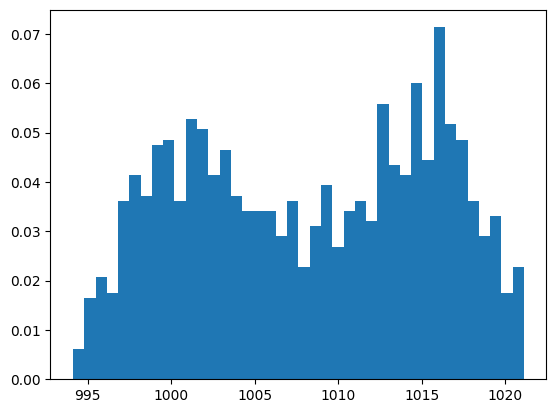

In [36]:
pressure = np.array(train_df["meanpressure"])
sorted_pressure = np.sort(pressure)
n = len(pressure)
plt.hist(sorted_pressure[int(0.01*n):int(0.99*n)], bins=40, density=True)
plt.show()


np.mean(pressure)

pressure_inf = sorted_pressure[int(0.01*n)]
pressure_sup = sorted_pressure[int(0.99*n)]

train_df["meanpressure_clipped"] = train_df["meanpressure"].clip(lower=pressure_inf, upper=pressure_sup)
test_df["meanpressure_clipped"] = test_df["meanpressure"].clip(lower=pressure_inf, upper=pressure_sup)


 ### Plotting the temperature series to get an initial sense of its temporal structure

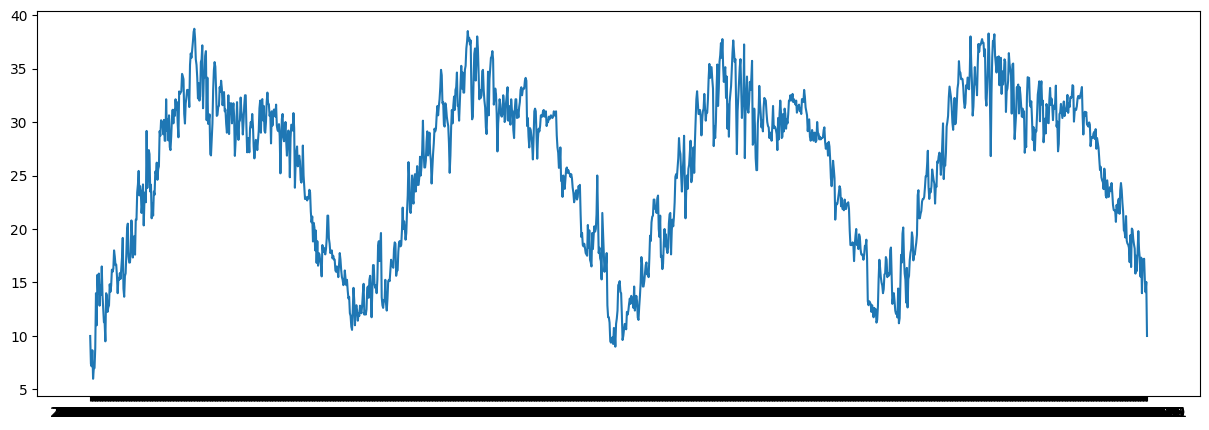

In [37]:
plt.figure(figsize=(15,5))
plt.plot(train_df["date"], train_df["meantemp"])
plt.show()


 As expected, the temperature exhibits a clear cyclical pattern.
 Capturing this periodic structure will be essential for accurate prediction.


 Next, I examine the distributions of the input variables.

C:\Users\tiots\AppData\Local\Temp\ipykernel_8224\3336102658.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,0].legend()


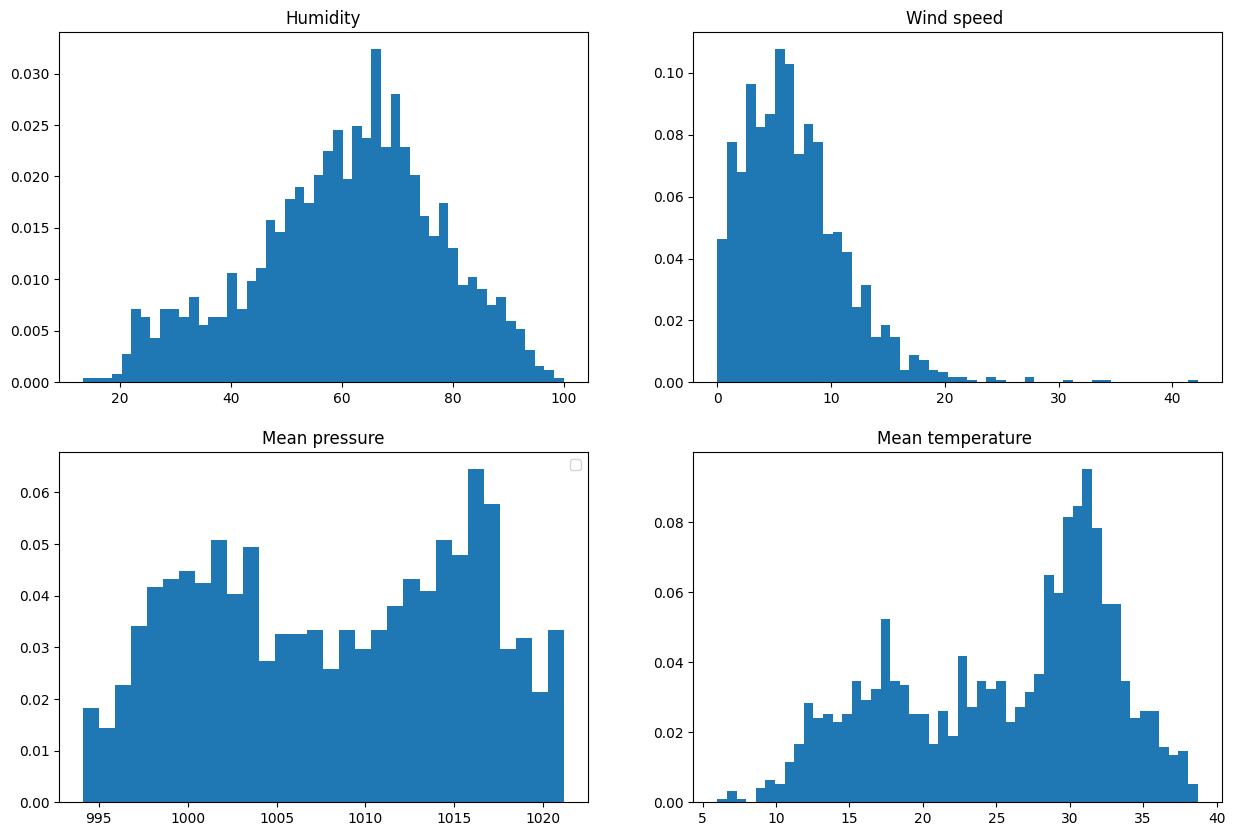

In [38]:
### Exploring other features
fig, ax = plt.subplots(figsize=(15,10), nrows=2, ncols=2)
ax[0,0].hist(train_df["humidity"], bins=50, density=True)
ax[0,0].set_title("Humidity")


ax[0,1].hist(train_df["wind_speed"], bins=50,density=True)
ax[0,1].set_title("Wind speed ")

ax[1,0].hist(train_df["meanpressure_clipped"], bins=30,density=True)
ax[1,0].set_title("Mean pressure")
ax[1,0].legend()

ax[1,1].hist(train_df["meantemp"], bins=50,density=True)
ax[1,1].set_title("Mean temperature ")
plt.show()

In [39]:
### To get things going, I convert the date into a number
train_df["date"] = pd.to_datetime(train_df["date"])
origine = train_df["date"].min()
train_df["date_num"] = train_df["date"] - origine
train_df["date_num"] = train_df["date_num"].dt.days

train_df = train_df.drop(columns=["date"])

### To get things going, I convert the date into a number
test_df["date"] = pd.to_datetime(test_df["date"])
test_df["date_num"] = test_df["date"] - origine
test_df["date_num"] = test_df["date_num"].dt.days

test_df = test_df.drop(columns=["date"])

In [40]:
train_df.head()

,meantemp,humidity,wind_speed,meanpressure,meanpressure_clipped,date_num
0,10.000000,84.500000,0.000000,1015.666667,1015.666667,0
1,7.400000,92.000000,2.980000,1017.800000,1017.800000,1
2,7.166667,87.000000,4.633333,1018.666667,1018.666667,2
3,8.666667,71.333333,1.233333,1017.166667,1017.166667,3
4,6.000000,86.833333,3.700000,1016.500000,1016.500000,4



 Scaling the variables before training

In [41]:
!pip install statsforecast

In [42]:
from sklearn.preprocessing import StandardScaler
from statsforecast import StatsForecast
from statsforecast.models import AutoCES
import scipy.stats as sps

df = pd.DataFrame({
    "unique_id": "Temperature",
    "ds": train_df["date_num"],
    "y" : train_df["meantemp"]
})

In [43]:
sf = StatsForecast(
    models=[AutoCES(season_length=365, model='Z', alias = "CES_365"), AutoCES(season_length=31, model='Z', alias = "CES_31")],
    freq=1
)

forecast = sf.forecast(df=df, h=114, fitted=True)
fitted = sf.forecast_fitted_values()

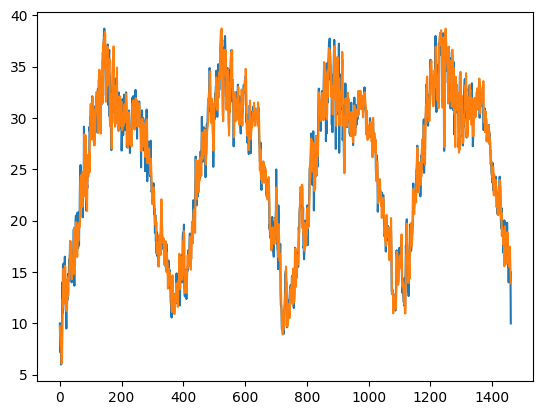

In [44]:
plt.plot(range(len(train_df)), train_df["meantemp"])
plt.plot(range(len(train_df)), fitted["CES_365"])

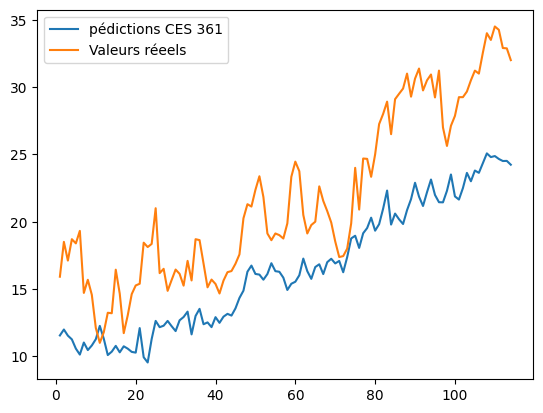

In [45]:
plt.plot(range(1,115), forecast["CES_365"], label="pédictions CES 361")
plt.plot(range(1,115),test_df["meantemp"], label="Valeurs réeels")
plt.legend()
plt.show()

In [46]:
### RMSE 
rmse = np.sqrt(np.mean((forecast['CES_365'] - test_df["meantemp"])**2))
print(f" The RMSE for the CES full forecasting on the test dataset  is {rmse:.2f}")

r2 = 1 - sum((forecast["CES_365"] - test_df["meantemp"])**2)/sum((test_df["meantemp"] - np.mean(test_df["meantemp"]))**2)
print(f"R^2 : {r2:.2f}")

 The RMSE for the CES full forecasting on the test dataset  is 5.83
R^2 : 0.15


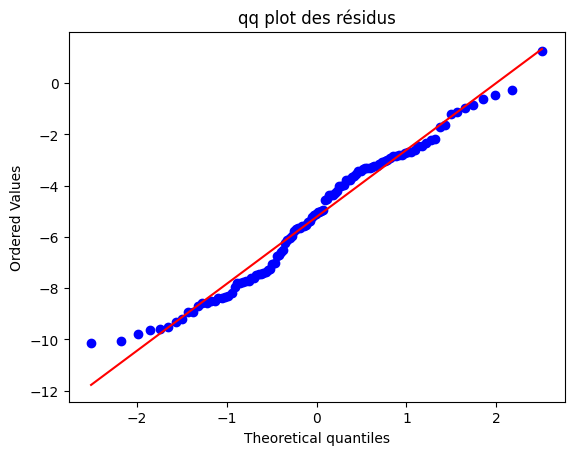

In [47]:
### qqplot for the residuals : 
residuals = forecast['CES_365'] - test_df["meantemp"]
sps.probplot(residuals, dist="norm", plot=plt)
plt.title("qq plot des résidus")
plt.show()

##### On a des résidus énormes et dont les quantiles s'alignent plus ou moins bien avec ceux de la loi normale. On va essayer de faire un rolling one step ahead pour comparer avec l'arima

In [48]:
def rolling_one_step(y_train, y_test, season_length=365, model_type="Z"):
    y_train = np.asarray(y_train, dtype=float)
    y_test = np.asarray(y_test, dtype=float)

    model = AutoCES(
        season_length=season_length,
        model=model_type,
        alias=f"CES_{season_length}"
    )

    # Fit once
    model.fit(y_train)

    preds = []

    for i in range(len(y_test)):
        # Series observed till y_test[i]:
        # train + true values already revealed
        y_seen = np.concatenate([y_train, y_test[:i]])

        # Forward = keeps the estimated parameters,
        # updates states until the last seen element
        fcst = model.forward(y=y_seen, h=1)

        preds.append(fcst["mean"][0])

    results = pd.DataFrame({
        "t": np.arange(len(y_test)),
        "y_true": y_test,
        "y_pred": preds,
        "residual": y_test - np.array(preds)
    })

    return results, model

In [49]:
results, model = rolling_one_step(train_df["meantemp"], test_df["meantemp"], season_length=365)

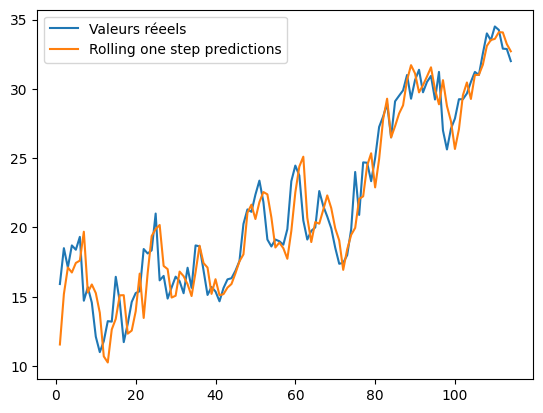

In [50]:
plt.plot(range(1,115),test_df["meantemp"], label="Valeurs réeels")
plt.plot(range(1,115), results["y_pred"], label="Rolling one step predictions")
plt.legend()
plt.show()

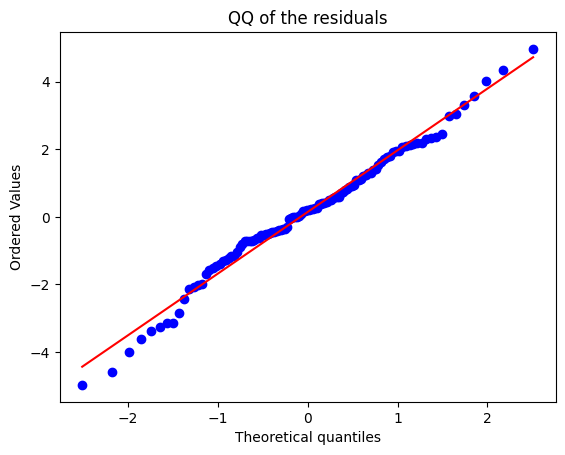

In [51]:
sps.probplot(results["residual"], dist='norm', plot=plt)
plt.title("QQ of the residuals")
plt.show()

In [52]:
### RMSE : 
rmse = np.sqrt(np.mean(results["residual"]**2))
print(f"RMSE for rolling one step predictions, CES : {rmse:.2f}")

r2 = 1 - sum((results["residual"])**2)/sum((test_df["meantemp"]- np.mean(test_df["meantemp"]))**2)
print(f"R^2 : {r2:.2f}")

RMSE for rolling one step predictions, CES : 1.81
R^2 : 0.92


#### Conclusion

The one time step prediction is not as accurate as the ARIMA, but the advantage of this approach is it's simplicity. We only had to train 2 parameters, without detrending, deseasonalizing the series, which makes it quite simple to use and train. The only problem is that for full forecasting, it is not better than the simple sinusoidal seasonal pattern + the trend pattern, which is why it yields a $R^2$ of nd a RMSE of $5.83$. 

#### Training a LSTM model 

In [62]:
y_train = np.array(train_df["meantemp"])
y_test = np.array(test_df["meantemp"])

In [63]:
import torch
import torch.nn as nn

In [64]:
def make_windows_multi_horizon(y, lookback, horizon = 114): ### Create the windows to be used to train and the values we're trying to predict
    X, Y = [], []
    for i in range(lookback, len(y)-horizon+1):
        X.append(y[i-lookback:i])
        Y.append(y[i:i+horizon])
    return np.array(X), np.array(Y)

train_size= int(0.8*len(y_train))
train = y_train[:train_size]
val = y_train[train_size:]


In [78]:
horizon = len(y_test)
X, Y = make_windows_multi_horizon(train, lookback=365, horizon = horizon)

In [79]:
class myLSTM (nn.Module):
    def __init__(self,
                 input_size=1,
                 hidden_size=64,
                 num_layers = 1,
                 horizon = 1, 
                 dropout= 0.0):
        super().__init__()
        
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first = True,
                            dropout = dropout if num_layers>1 else 0)
        
        self.fc = nn.Linear(hidden_size, horizon)
        
    def forward(self, x):
        ## I receive a batch: its shape is batch x lookback x 1
        out, _ = self.lstm(x)
        
        ## I retreive the last hidden state
        last_hidden = out[:,-1,:]
        
        ## forecast 
        forecast = self.fc(last_hidden)
        
        return forecast
        

In [80]:
scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_scaled = scaler.transform(y_test.reshape(-1,1)).ravel()


X_train, Y_train = make_windows_multi_horizon(y_train_scaled, lookback=365, horizon= 114)

In [81]:
print("X_train shape : ", X_train.shape)
print("Y_train shape : ", Y_train.shape)

X_train shape :  (984, 365)
Y_train shape :  (984, 114)


In [82]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)

dataset = torch.utils.data.TensorDataset(X_train_t, Y_train_t)
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle= True
)

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = myLSTM(input_size=1,
               hidden_size=64,
               num_layers=1,
               horizon = horizon,
               dropout= 0.0).to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay = 1e-4)

epochs = 300

for epoch in range(epochs):
    model.train() # Get in train mode 
    total_loss = 0
    for xb, yb in loader:
        xb = xb.to(device)  ##Load the x and y in the device
        yb = yb.to(device)
        
        optimizer.zero_grad()
        
        pred = model(xb)
        loss = criterion(pred, yb)
        
        loss.backward()### Compute the gradients
        optimizer.step() ### modify the parameters
        
        total_loss = loss.item()*xb.size(0) ### Non-normalized error for the batch
        
    avg_loss = total_loss/len(dataset)
    
    if (epoch+1)%50==0:
        print(f"Epoch {epoch+1}/{epochs}, train loss = {avg_loss:.6f}")
        